# Statistical & Machine-Learning Analysis of the Statlog (Landsat Satellite) Dataset

### A Data Science Mini-Project

**Dataset:** Statlog (Landsat Satellite) — UCI Machine Learning Repository
`https://archive.ics.uci.edu/ml/datasets/Statlog+(Landsat+Satellite)`

---

### Project Tasks Covered in this Notebook
- **Part A — Data Preprocessing & Preliminary (Statistical) Analysis**
- **Part B — ML Classification: k-NN vs. SVM** (Accuracy, Cohen's Kappa, ROC/AUC)
- **Part C — Clustering: K-Means vs. DBSCAN** (Entropy, SSE)
- **Summary of Inferences & Answers to Research Questions**

Each part is organised into its own numbered section below, with a short explanation of *why* each
step is performed, immediately followed by the code and its output.


## Part 1 Setup: Libraries & Global Configuration

We use **Python** with `pandas`/`numpy` for data handling, `matplotlib`/`seaborn` for
visualisation, and `scikit-learn` for statistics, classification and clustering. A fixed
`RANDOM_STATE` is used everywhere a random process is involved, so that all results in this
notebook are exactly reproducible.


In [3]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import entropy as scipy_entropy

from sklearn.preprocessing import StandardScaler, label_binarize
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier, NearestNeighbors
from sklearn.svm import SVC
from sklearn.cluster import KMeans, DBSCAN
from sklearn.decomposition import PCA
from sklearn.metrics import (accuracy_score, cohen_kappa_score, confusion_matrix,
                              classification_report, roc_curve, auc, roc_auc_score,
                              silhouette_score)

%matplotlib inline
sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 100
plt.rcParams['font.size'] = 10
plt.rcParams['axes.titleweight'] = 'bold'

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# Class code -> descriptive name (from the dataset documentation, sat.doc)
CLASS_NAMES = {1: 'Red Soil', 2: 'Cotton Crop', 3: 'Grey Soil',
               4: 'Damp Grey Soil', 5: 'Soil w/ Veg. Stubble', 7: 'Very Damp Grey Soil'}
CLASS_ORDER = [1, 2, 3, 4, 5, 7]   # class 6 does not occur in this dataset (per documentation)
PALETTE = dict(zip(CLASS_ORDER, sns.color_palette('tab10', len(CLASS_ORDER))))

pd.set_option('display.max_columns', 40)
pd.set_option('display.width', 140)

print("Libraries loaded successfully. Random seed fixed at", RANDOM_STATE)


Libraries loaded successfully. Random seed fixed at 42


## Part 2 : Dataset Description & Loading

**Source:** UCI Machine Learning Repository — *Statlog (Landsat Satellite)* dataset, contributed by
Ashwin Srinivasan (University of Strathclyde), originally generated from NASA Landsat Multi-Spectral
Scanner (MSS) imagery of a scene in Australia, provided by the Centre for Remote Sensing, University
of New South Wales.

**What each row represents:** one 3×3 neighbourhood of pixels from a satellite image. For every
neighbourhood, the multi-spectral intensity of each of the 9 pixels is recorded in **4 spectral
bands** (2 visible: green, red; 2 near-infrared), giving **9 × 4 = 36 numeric attributes**, each an
integer pixel intensity in the 8-bit range 0–255. The label is the land-cover class of the *central*
pixel of the neighbourhood, one of:

| Code | Class |
|---|---|
| 1 | Red soil |
| 2 | Cotton crop |
| 3 | Grey soil |
| 4 | Damp grey soil |
| 5 | Soil with vegetation stubble |
| 7 | Very damp grey soil |

*(Class 6 — "mixture class" — was dropped by the original curators and never appears in the data.)*

**File structure (as provided by UCI, and used unmodified below):**
- `sat.trn` — 4435 rows (training set)
- `sat.tst` — 2000 rows (test set)

The dataset documentation explicitly instructs: *"do NOT use cross-validation with this dataset —
just train and test only once with the above training and test sets."* 
Part B (classification): the official test set is touched **exactly once**, only for final
evaluation, after all hyperparameter tuning is done on a validation split carved out of the training
set alone.

We name the 36 columns descriptively as `<position>_<band>`, where position ∈ {top-left (TL),
top-middle (TM), top-right (TR), middle-left (ML), middle-middle/central (MM), middle-right (MR),
bottom-left (BL), bottom-middle (BM), bottom-right (BR)} and band ∈ {Green, Red, NIR1, NIR2}, matching
the order specified in the original documentation (`sat.doc`).


In [4]:
positions = ['TL', 'TM', 'TR', 'ML', 'MM', 'MR', 'BL', 'BM', 'BR']   # MM = central pixel
bands = ['Green', 'Red', 'NIR1', 'NIR2']
col_names = [f"{p}_{b}" for p in positions for b in bands]
col_names_full = col_names + ['class']
assert len(col_names) == 36

df_train = pd.read_csv('sat.trn', sep=r'\s+', header=None, names=col_names_full)
df_test  = pd.read_csv('sat.tst', sep=r'\s+', header=None, names=col_names_full)

print(f"Training set : {df_train.shape[0]:>5} rows  x  {df_train.shape[1]} columns (36 features + 1 class label)")
print(f"Test set     : {df_test.shape[0]:>5} rows  x  {df_test.shape[1]} columns")
print(f"Total        : {df_train.shape[0] + df_test.shape[0]} rows\n")
df_train.head()


Training set :  4435 rows  x  37 columns (36 features + 1 class label)
Test set     :  2000 rows  x  37 columns
Total        : 6435 rows



,TL_Green,TL_Red,TL_NIR1,TL_NIR2,TM_Green,TM_Red,TM_NIR1,TM_NIR2,TR_Green,TR_Red,TR_NIR1,TR_NIR2,ML_Green,ML_Red,ML_NIR1,ML_NIR2,MM_Green,MM_Red,MM_NIR1,MM_NIR2,MR_Green,MR_Red,MR_NIR1,MR_NIR2,BL_Green,BL_Red,BL_NIR1,BL_NIR2,BM_Green,BM_Red,BM_NIR1,BM_NIR2,BR_Green,BR_Red,BR_NIR1,BR_NIR2,class
0,92,115,120,94,84,102,106,79,84,102,102,83,101,126,133,103,92,112,118,85,84,103,104,81,102,126,134,104,88,121,128,100,84,107,113,87,3
1,84,102,106,79,84,102,102,83,80,102,102,79,92,112,118,85,84,103,104,81,84,99,104,78,88,121,128,100,84,107,113,87,84,99,104,79,3
2,84,102,102,83,80,102,102,79,84,94,102,79,84,103,104,81,84,99,104,78,84,99,104,81,84,107,113,87,84,99,104,79,84,99,104,79,3
3,80,102,102,79,84,94,102,79,80,94,98,76,84,99,104,78,84,99,104,81,76,99,104,81,84,99,104,79,84,99,104,79,84,103,104,79,3
4,84,94,102,79,80,94,98,76,80,102,102,79,84,99,104,81,76,99,104,81,76,99,108,85,84,99,104,79,84,103,104,79,79,107,109,87,3


## Part 3 : Data Preprocessing

**Why preprocessing is (mostly) light here:** unlike many real-world datasets, this one is already
purely **numerical** (as the assignment requires), with no categorical columns to encode. We still
run the standard checks below and justify each preprocessing decision.


In [ ]:
print("="*60)
print("MISSING VALUES")
print("="*60)
print(f"Training set missing values : {df_train.isna().sum().sum()}")
print(f"Test set missing values     : {df_test.isna().sum().sum()}")

print("\n" + "="*60)
print("DUPLICATE ROWS")
print("="*60)
print(f"Duplicate rows in training set : {df_train.duplicated().sum()}")
print(f"Duplicate rows in test set     : {df_test.duplicated().sum()}")
print(f"Rows in test set also seen in training set: "
      f"{pd.merge(df_train, df_test, how='inner').shape[0]}")

print("\n" + "="*60)
print("DATA TYPES & VALUE RANGE")
print("="*60)
print("Column dtypes:", df_train[col_names].dtypes.unique())
print(f"Global min / max across all 36 features (train): "
      f"{df_train[col_names].min().min()} / {df_train[col_names].max().max()}  "
      f"(expected within 0-255 for 8-bit imagery)")

print("\n" + "="*60)
print("CLASS DISTRIBUTION")
print("="*60)
train_counts = df_train['class'].value_counts().sort_index()
test_counts  = df_test['class'].value_counts().sort_index()
dist_table = pd.DataFrame({'Class': [CLASS_NAMES[c] for c in train_counts.index],
                            'Train count': train_counts.values,
                            'Train %': (100*train_counts.values/train_counts.sum()).round(1),
                            'Test count': test_counts.reindex(train_counts.index).values,
                            'Test %': (100*test_counts.reindex(train_counts.index).values/test_counts.sum()).round(1)},
                           index=train_counts.index)
dist_table


MISSING VALUES
Training set missing values : 0
Test set missing values     : 0

DUPLICATE ROWS
Duplicate rows in training set : 0
Duplicate rows in test set     : 0
Rows in test set also seen in training set: 0

DATA TYPES & VALUE RANGE
Column dtypes: [dtype('int64')]
Global min / max across all 36 features (train): 27 / 157  (expected within 0-255 for 8-bit imagery)

CLASS DISTRIBUTION


,Class,Train count,Train %,Test count,Test %
class,,,,,
1,Red Soil,1072,24.2,461,23.0
2,Cotton Crop,479,10.8,224,11.2
3,Grey Soil,961,21.7,397,19.8
4,Damp Grey Soil,415,9.4,211,10.6
5,Soil w/ Veg. Stubble,470,10.6,237,11.8
7,Very Damp Grey Soil,1038,23.4,470,23.5


In [6]:
# Add a human-readable class-name column for plotting (kept separate from the numeric 'class' target)
df_train['class_name'] = df_train['class'].map(CLASS_NAMES)
df_test['class_name'] = df_test['class'].map(CLASS_NAMES)

# Variance per feature - motivates why we standardise before any distance-based algorithm
var_by_band = {b: df_train[[c for c in col_names if c.endswith(b)]].values.std() for b in bands}
print("Standard deviation of raw pixel intensities, pooled by spectral band (training set):")
for b, v in var_by_band.items():
    print(f"  {b:6s}: std = {v:6.2f}")
print("\n--> Bands do not share the same spread, which justifies standardising all 36 features")
print("    to zero mean / unit variance before applying any distance-based algorithm.")


Standard deviation of raw pixel intensities, pooled by spectral band (training set):
  Green : std =  13.56
  Red   : std =  22.79
  NIR1  : std =  16.69
  NIR2  : std =  18.84

--> Bands do not share the same spread, which justifies standardising all 36 features
    to zero mean / unit variance before applying any distance-based algorithm.


## Part 4 : Preliminary Statistical Analysis (I): Descriptive Statistics & Normality

We compute standard descriptive statistics (mean, standard deviation, quartiles, skewness,
kurtosis) for every one of the 36 attributes, and formally test whether the central-pixel bands
follow a Normal distribution. This matters because several classical statistical procedures (e.g.
Pearson correlation, ANOVA's assumptions) are commonly motivated by approximate normality, and
because skewed / heavy-tailed features are good candidates for standardisation (already planned
above) rather than more aggressive transforms.

We use the **D'Agostino–Pearson K² test** (`scipy.stats.normaltest`) rather than Shapiro–Wilk,
because Shapiro–Wilk's accuracy degrades on large samples (n > ~2000), while D'Agostino–Pearson
remains a reliable omnibus test of skewness + kurtosis at n = 4435.


In [7]:
desc_stats = df_train[col_names].describe().T
desc_stats['skewness'] = df_train[col_names].skew()
desc_stats['kurtosis'] = df_train[col_names].kurtosis()
desc_stats.round(2)


,count,mean,std,min,25%,50%,75%,max,skewness,kurtosis
TL_Green,4435.0,69.47,13.65,40.0,60.0,68.0,80.0,104.0,0.04,-0.74
TL_Red,4435.0,83.86,22.73,27.0,71.0,87.0,103.0,137.0,-0.66,-0.22
TL_NIR1,4435.0,99.32,16.67,56.0,85.0,101.0,113.0,140.0,-0.12,-0.89
TL_NIR2,4435.0,82.56,18.70,33.0,70.0,83.0,92.0,154.0,0.88,1.31
TM_Green,4435.0,69.21,13.55,40.0,60.0,68.0,80.0,102.0,0.06,-0.73
TM_Red,4435.0,83.50,22.81,27.0,71.0,85.0,103.0,137.0,-0.64,-0.27
TM_NIR1,4435.0,99.17,16.63,50.0,85.0,101.0,113.0,145.0,-0.12,-0.91
TM_NIR2,4435.0,82.48,18.71,29.0,69.0,81.0,92.0,157.0,0.89,1.29
TR_Green,4435.0,68.96,13.50,40.0,60.0,67.0,79.0,104.0,0.06,-0.72
TR_Red,4435.0,83.13,22.81,27.0,71.0,85.0,103.0,130.0,-0.64,-0.30


In [8]:
print("D'Agostino-Pearson normality test (K^2) on the 4 CENTRAL-pixel bands (attributes 17-20):")
print("H0: the feature is normally distributed.  alpha = 0.05\n")
for c in ['MM_Green', 'MM_Red', 'MM_NIR1', 'MM_NIR2']:
    stat, p = stats.normaltest(df_train[c])
    verdict = "REJECT H0 -> NOT normal" if p < 0.05 else "fail to reject H0 -> approx. normal"
    print(f"  {c:10s}: statistic = {stat:9.2f}   p-value = {p:.3e}   =>  {verdict}")

print("\nInference: every central-pixel band significantly departs from normality, consistent with")
print("the multi-modal nature of the data (6 distinct land-cover classes, each with its own")
print("characteristic reflectance, mixed together in the marginal distribution of each band).")


D'Agostino-Pearson normality test (K^2) on the 4 CENTRAL-pixel bands (attributes 17-20):
H0: the feature is normally distributed.  alpha = 0.05

  MM_Green  : statistic =    270.58   p-value = 1.755e-59   =>  REJECT H0 -> NOT normal
  MM_Red    : statistic =    284.23   p-value = 1.911e-62   =>  REJECT H0 -> NOT normal
  MM_NIR1   : statistic =    741.33   p-value = 1.051e-161   =>  REJECT H0 -> NOT normal
  MM_NIR2   : statistic =    569.87   p-value = 1.795e-124   =>  REJECT H0 -> NOT normal

Inference: every central-pixel band significantly departs from normality, consistent with
the multi-modal nature of the data (6 distinct land-cover classes, each with its own
characteristic reflectance, mixed together in the marginal distribution of each band).


## Part 5 : Preliminary Statistical Analysis (II): Correlation Structure

**Purpose:** to understand (a) how strongly the 4 spectral bands relate to each other physically,
and (b) how strongly neighbouring pixels relate to each other spatially. Both are expected to be
high in satellite imagery — nearby pixels usually belong to the same land-cover patch, and the two
visible bands (Green, Red) / two infra-red bands (NIR1, NIR2) are physically correlated because they
respond to overlapping surface properties.


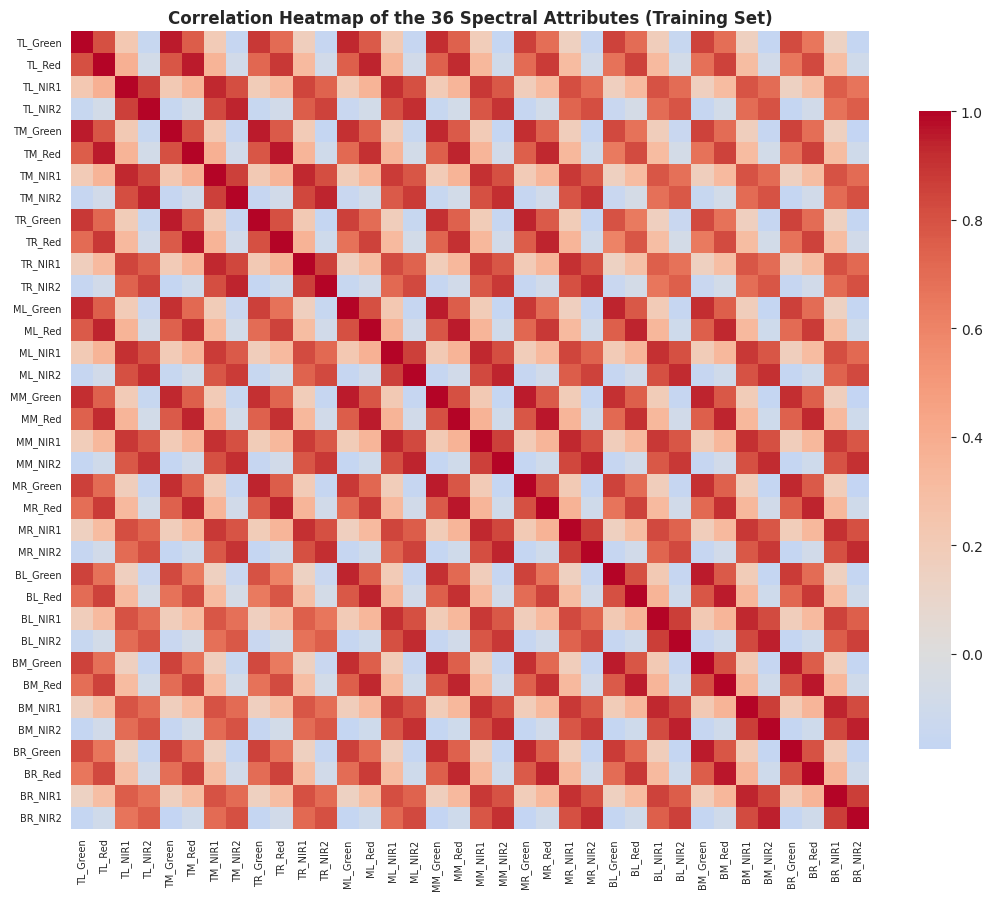

In [9]:
corr = df_train[col_names].corr()

plt.figure(figsize=(11, 9))
sns.heatmap(corr, cmap='coolwarm', center=0, square=True, cbar_kws={'shrink': 0.8},
            xticklabels=True, yticklabels=True)
plt.title('Correlation Heatmap of the 36 Spectral Attributes (Training Set)')
plt.xticks(fontsize=7, rotation=90)
plt.yticks(fontsize=7)
plt.tight_layout()
plt.show()


In [10]:
print("Correlation among the 4 CENTRAL-pixel bands (attributes 17-20):")
print(corr.loc[['MM_Green','MM_Red','MM_NIR1','MM_NIR2'], ['MM_Green','MM_Red','MM_NIR1','MM_NIR2']].round(3))

print("\nMean pairwise correlation of the SAME band across the 9 neighbourhood pixels (spatial correlation):")
for b in bands:
    cols_b = [c for c in col_names if c.endswith(b)]
    sub = corr.loc[cols_b, cols_b].values
    mean_corr = (sub.sum() - len(cols_b)) / (len(cols_b)**2 - len(cols_b))
    print(f"  Band {b:6s}: mean pairwise correlation across the 9-pixel neighbourhood = {mean_corr:.3f}")

print("\nInferences:")
print(" - Green and Red (both visible bands) are strongly positively correlated (r ~ 0.8):")
print("   both respond similarly to soil brightness.")
print(" - NIR1 and NIR2 are strongly positively correlated (r ~ 0.87): both respond to vegetation/moisture.")
print(" - Visible bands correlate weakly/negatively with NIR bands, consistent with vegetation")
print("   reflecting NIR strongly while absorbing visible light (classic spectral signature).")
print(" - Same-band correlation across neighbouring pixels is very high (>0.9), confirming strong")
print("   spatial autocorrelation - i.e. substantial redundancy among the 36 raw attributes.")


Correlation among the 4 CENTRAL-pixel bands (attributes 17-20):
          MM_Green  MM_Red  MM_NIR1  MM_NIR2
MM_Green     1.000   0.805    0.211   -0.166
MM_Red       0.805   1.000    0.366   -0.095
MM_NIR1      0.211   0.366    1.000    0.866
MM_NIR2     -0.166  -0.095    0.866    1.000

Mean pairwise correlation of the SAME band across the 9 neighbourhood pixels (spatial correlation):
  Band Green : mean pairwise correlation across the 9-pixel neighbourhood = 0.896
  Band Red   : mean pairwise correlation across the 9-pixel neighbourhood = 0.899
  Band NIR1  : mean pairwise correlation across the 9-pixel neighbourhood = 0.862
  Band NIR2  : mean pairwise correlation across the 9-pixel neighbourhood = 0.869

Inferences:
 - Green and Red (both visible bands) are strongly positively correlated (r ~ 0.8):
   both respond similarly to soil brightness.
 - NIR1 and NIR2 are strongly positively correlated (r ~ 0.87): both respond to vegetation/moisture.
 - Visible bands correlate weakly/nega

## Part 6 : Preliminary Statistical Analysis (III): Which Features Discriminate the Classes?

**Purpose:** before building any classifier, we ask — statistically — *which* of the 36 attributes
actually differ across the 6 land-cover classes. We use a **one-way ANOVA** per feature (comparing
the feature's mean across the 6 class groups). A large F-statistic (and correspondingly tiny
p-value) indicates a feature whose between-class variance greatly exceeds its within-class variance
— i.e. a feature that is highly informative for classification. This directly motivates and
previews the classification results in Part B.


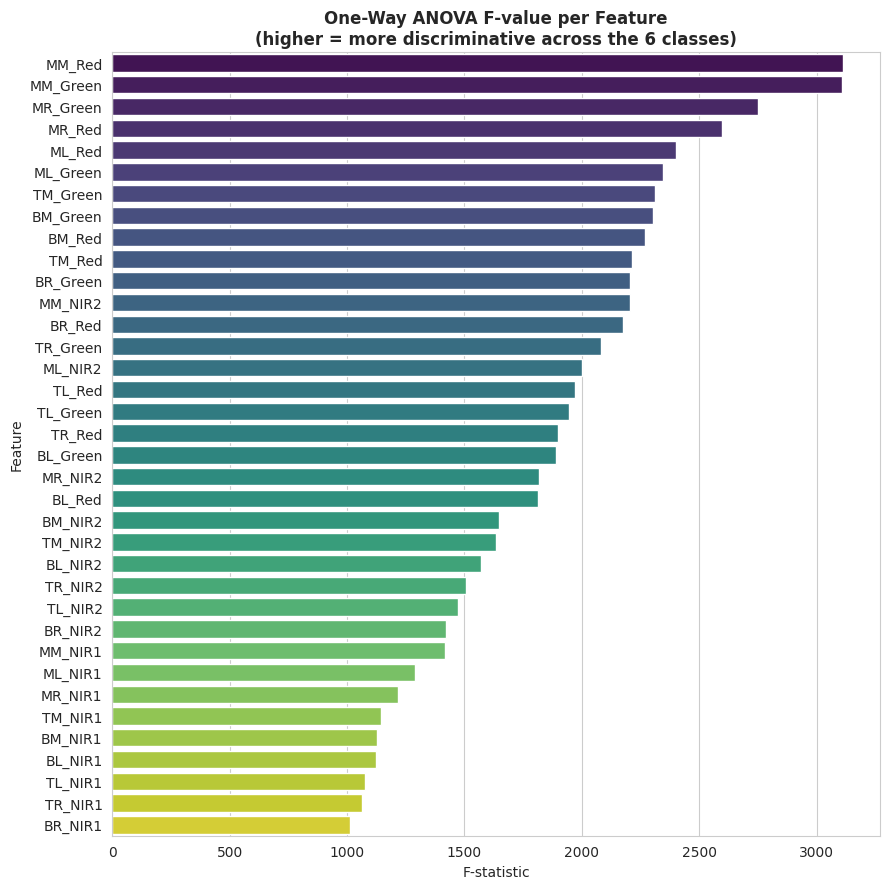

Top 8 most discriminative features:
 Feature     F_value  p_value
  MM_Red 3114.570992      0.0
MM_Green 3108.572768      0.0
MR_Green 2751.123818      0.0
  MR_Red 2599.063507      0.0
  ML_Red 2402.857416      0.0
ML_Green 2344.670769      0.0
TM_Green 2310.377954      0.0
BM_Green 2301.556126      0.0

Bottom 5 least discriminative features:
Feature     F_value  p_value
BM_NIR1 1126.758139      0.0
BL_NIR1 1124.859614      0.0
TL_NIR1 1076.966754      0.0
TR_NIR1 1062.497827      0.0
BR_NIR1 1011.737294      0.0

All 36 of 36 features are statistically significant at alpha=0.05 -- every attribute carries some class information, but the Red and Green bands of the central/neighbouring pixels are consistently the strongest, while the NIR1 band is comparatively the weakest discriminator.


In [11]:
anova_rows = []
groups = [df_train[df_train['class'] == c] for c in CLASS_ORDER]
for col in col_names:
    f_val, p_val = stats.f_oneway(*[g[col].values for g in groups])
    anova_rows.append((col, f_val, p_val))
anova_df = pd.DataFrame(anova_rows, columns=['Feature', 'F_value', 'p_value'])
anova_df = anova_df.sort_values('F_value', ascending=False).reset_index(drop=True)

plt.figure(figsize=(9, 9))
sns.barplot(data=anova_df, y='Feature', x='F_value', hue='Feature',
            palette='viridis', legend=False)
plt.title('One-Way ANOVA F-value per Feature\n(higher = more discriminative across the 6 classes)')
plt.xlabel('F-statistic')
plt.tight_layout()
plt.show()

print("Top 8 most discriminative features:")
print(anova_df.head(8).to_string(index=False))
print("\nBottom 5 least discriminative features:")
print(anova_df.tail(5).to_string(index=False))
print(f"\nAll {(anova_df['p_value'] < 0.05).sum()} of {len(anova_df)} features are statistically "
      f"significant at alpha=0.05 -- every attribute carries some class information, but the Red "
      f"and Green bands of the central/neighbouring pixels are consistently the strongest, while "
      f"the NIR1 band is comparatively the weakest discriminator.")


## Part 7  Exploratory Visualisation (I): Class Distribution


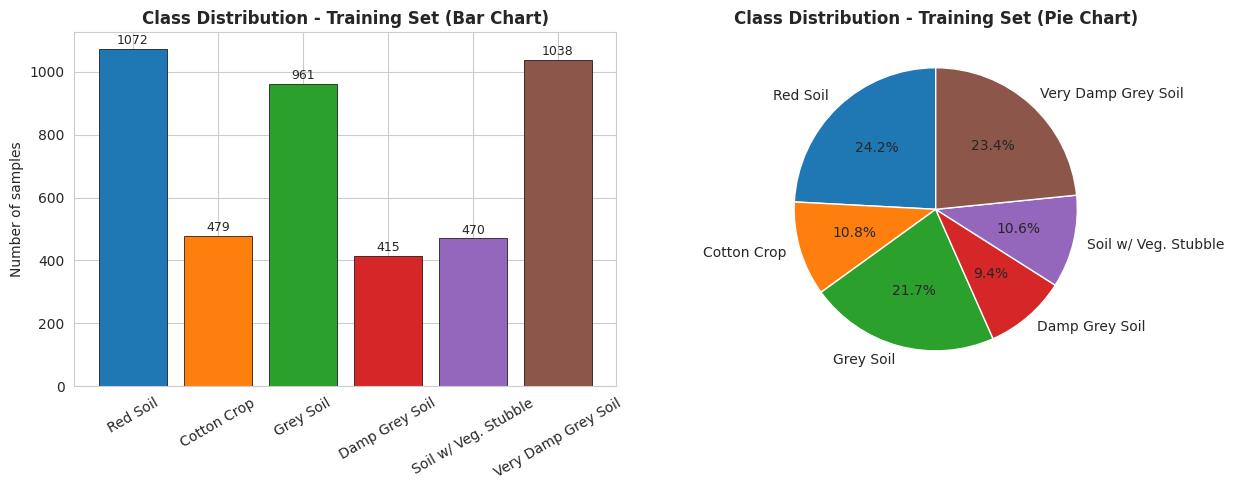

Most frequent class : Red Soil (1072 samples, 24.2%)
Least frequent class: Damp Grey Soil (415 samples, 9.4%)
Imbalance ratio (max/min) = 2.58x -- moderate imbalance, not severe enough to require resampling, but justifies using macro-averaged metrics
(macro accuracy is not needed since overall accuracy is standard, but macro-F1/Kappa/AUC
give every class equal weight regardless of its size) in Part B.


In [12]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
counts = df_train['class'].value_counts().reindex(CLASS_ORDER)
labels = [CLASS_NAMES[c] for c in CLASS_ORDER]
colors = [PALETTE[c] for c in CLASS_ORDER]

axes[0].bar(labels, counts.values, color=colors, edgecolor='black', linewidth=0.5)
axes[0].set_title('Class Distribution - Training Set (Bar Chart)')
axes[0].set_ylabel('Number of samples')
axes[0].tick_params(axis='x', rotation=30)
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 15, str(v), ha='center', fontsize=9)

axes[1].pie(counts.values, labels=labels, colors=colors, autopct='%1.1f%%', startangle=90,
            wedgeprops={'edgecolor': 'white', 'linewidth': 1})
axes[1].set_title('Class Distribution - Training Set (Pie Chart)')
plt.tight_layout()
plt.show()

print(f"Most frequent class : {CLASS_NAMES[counts.idxmax()]} ({counts.max()} samples, "
      f"{100*counts.max()/counts.sum():.1f}%)")
print(f"Least frequent class: {CLASS_NAMES[counts.idxmin()]} ({counts.min()} samples, "
      f"{100*counts.min()/counts.sum():.1f}%)")
print(f"Imbalance ratio (max/min) = {counts.max()/counts.min():.2f}x -- moderate imbalance, "
      f"not severe enough to require resampling, but justifies using macro-averaged metrics")
print("(macro accuracy is not needed since overall accuracy is standard, but macro-F1/Kappa/AUC")
print("give every class equal weight regardless of its size) in Part B.")


## Part 8 : Exploratory Visualisation (II): Feature Distributions by Class

We focus on the 4 **central-pixel** bands (attributes 17–20), since the documentation notes these
alone are sufficient to avoid neighbourhood-boundary issues, and they represent the pixel actually
being classified. KDE plots show how each band's distribution differs by class; boxplots
additionally reveal spread and outliers.


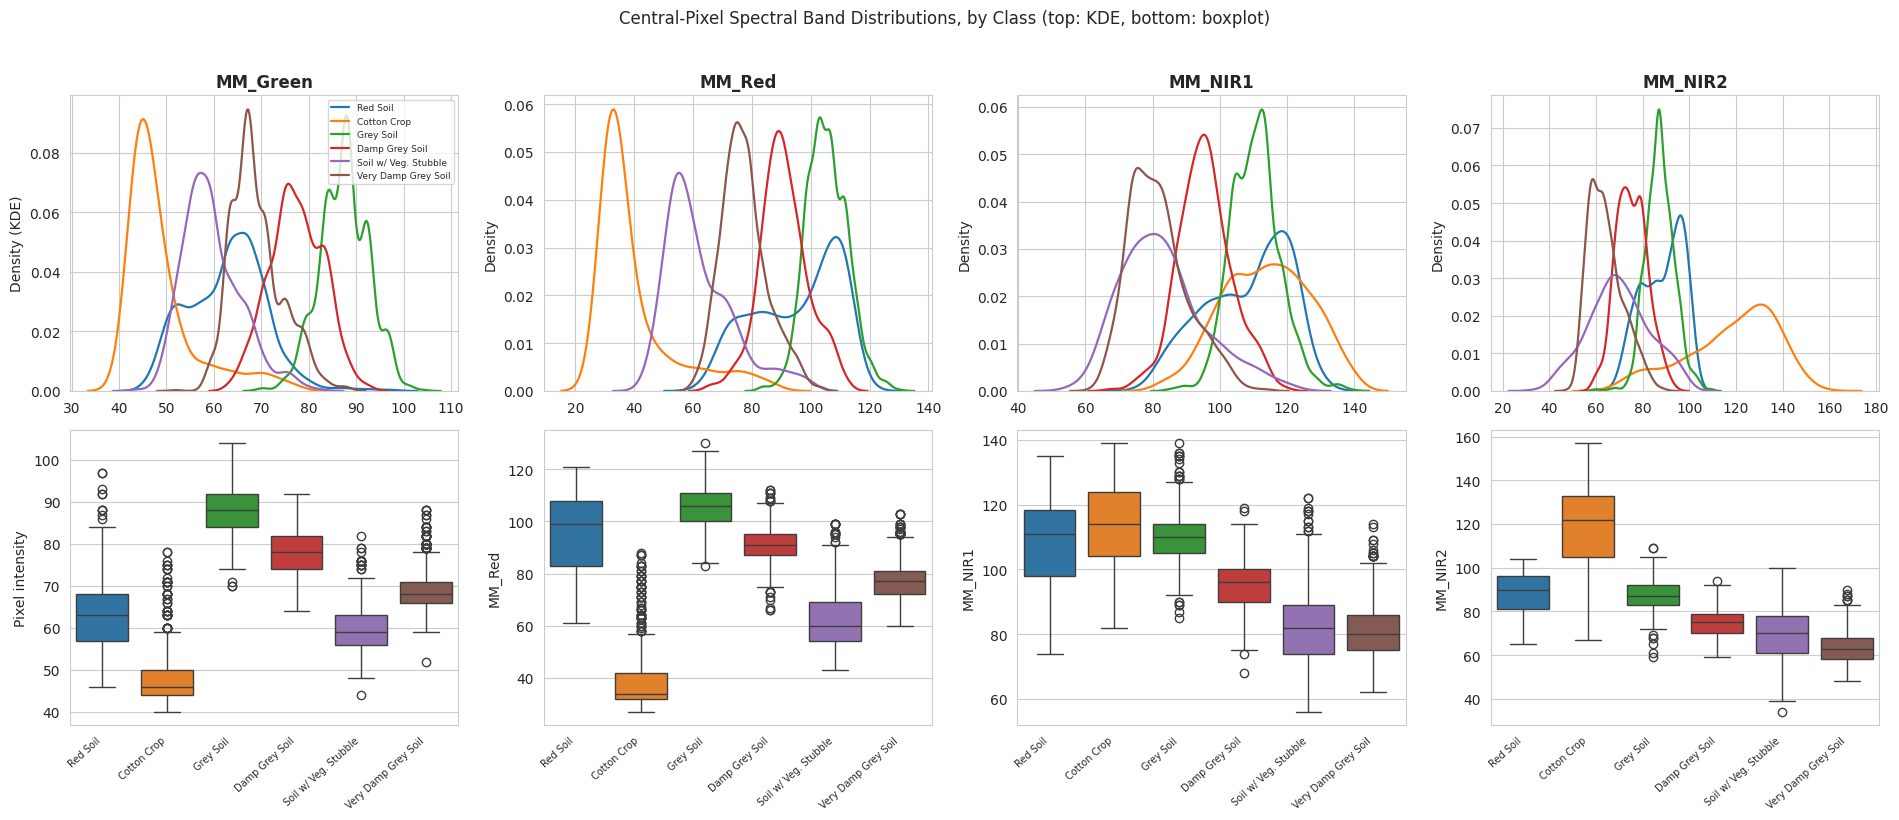

In [13]:
central_bands = ['MM_Green', 'MM_Red', 'MM_NIR1', 'MM_NIR2']

fig, axes = plt.subplots(2, 4, figsize=(19, 8))
for i, cb in enumerate(central_bands):
    ax = axes[0, i]
    for c in CLASS_ORDER:
        sns.kdeplot(df_train.loc[df_train['class'] == c, cb], ax=ax,
                    label=CLASS_NAMES[c], color=PALETTE[c], linewidth=1.6)
    ax.set_title(f'{cb}')
    ax.set_xlabel('')
    if i == 0:
        ax.legend(fontsize=6.5)

    ax2 = axes[1, i]
    sns.boxplot(data=df_train, x='class', y=cb, order=CLASS_ORDER,
                palette=PALETTE, hue='class', legend=False, ax=ax2)
    ax2.set_xticklabels([CLASS_NAMES[c] for c in CLASS_ORDER], rotation=42, ha='right', fontsize=7)
    ax2.set_xlabel('')

axes[0, 0].set_ylabel('Density (KDE)')
axes[1, 0].set_ylabel('Pixel intensity')
fig.suptitle('Central-Pixel Spectral Band Distributions, by Class (top: KDE, bottom: boxplot)', y=1.02)
plt.tight_layout()
plt.show()


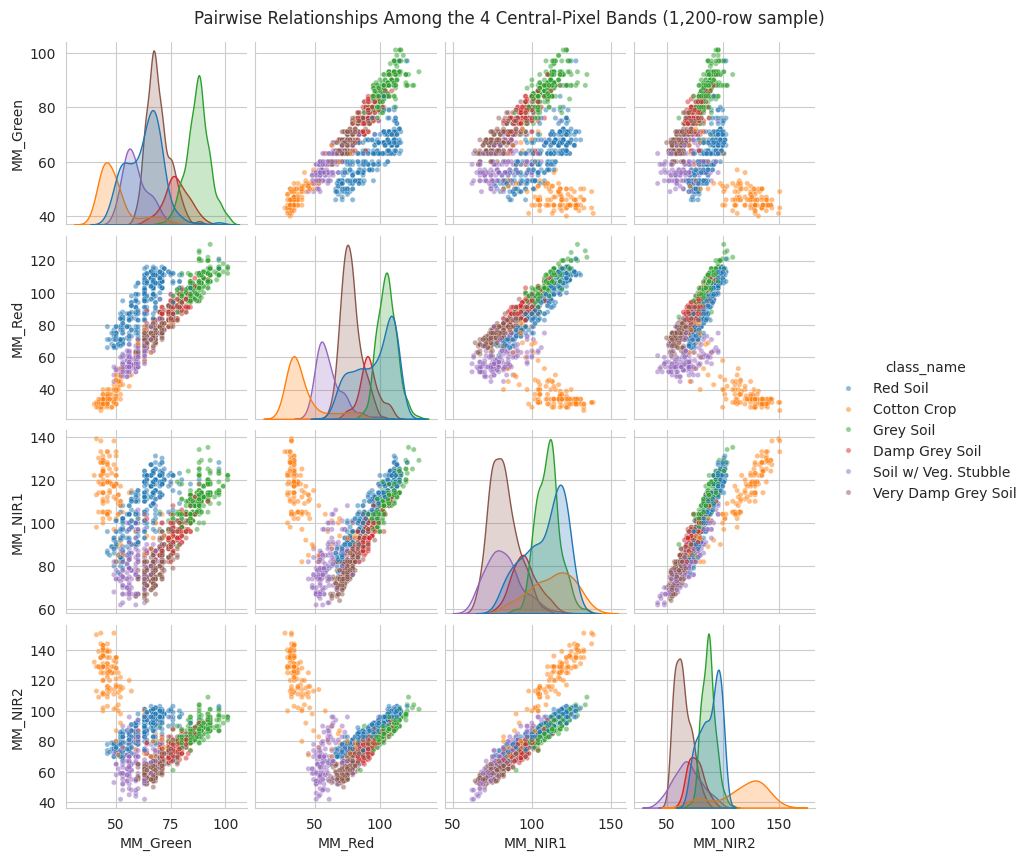

Inference: 'Cotton crop' (class 2) and 'Red soil' (class 1) separate fairly cleanly on
NIR1/NIR2 vs Green/Red, while the three grey-soil variants (Grey soil, Damp grey soil, Very
damp grey soil) show strongly overlapping distributions across all four bands - a first
visual hint that these three classes will be the hardest for any classifier to separate.


In [14]:
sample_df = df_train.sample(1200, random_state=RANDOM_STATE)
g = sns.pairplot(sample_df, vars=central_bands, hue='class_name',
                  hue_order=[CLASS_NAMES[c] for c in CLASS_ORDER],
                  palette={CLASS_NAMES[c]: PALETTE[c] for c in CLASS_ORDER},
                  plot_kws={'alpha': 0.5, 's': 14}, diag_kind='kde', height=2.1)
g.fig.suptitle('Pairwise Relationships Among the 4 Central-Pixel Bands (1,200-row sample)', y=1.02)
plt.show()

print("Inference: 'Cotton crop' (class 2) and 'Red soil' (class 1) separate fairly cleanly on")
print("NIR1/NIR2 vs Green/Red, while the three grey-soil variants (Grey soil, Damp grey soil, Very")
print("damp grey soil) show strongly overlapping distributions across all four bands - a first")
print("visual hint that these three classes will be the hardest for any classifier to separate.")


## Part 9 : Exploratory Visualisation (III): Dimensionality Reduction (PCA)

**Purpose:** with 36 correlated attributes (Part 5 showed strong redundancy), Principal Component
Analysis lets us visualise the entire feature space in 2 dimensions and see, informally, how
separable the 6 classes already are before any classifier is trained. This also quantifies how much
of the total variance is genuinely "new" information vs. redundant.


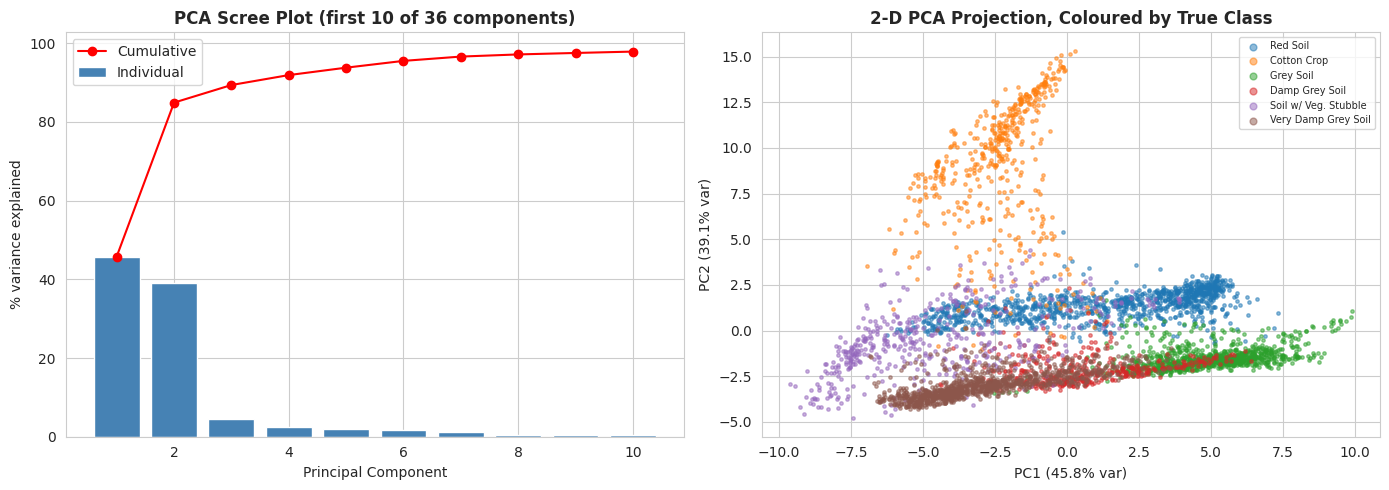

First 2 PCs explain  84.9% of total variance
First 6 PCs explain  95.5% of total variance
First 10 PCs explain 97.9% of total variance

Inference: because of the heavy redundancy identified in Part 5 (highly correlated bands and
neighbouring pixels), a small number of principal components captures most of the variance.
Even in just 2 dimensions, several classes (notably Cotton crop and Red soil) already form
visually distinct clusters, while the grey-soil variants overlap substantially - foreshadowing
both the classification and clustering results below.


In [15]:
scaler_pca = StandardScaler()
X_train_scaled_pca = scaler_pca.fit_transform(df_train[col_names])

pca_full = PCA(random_state=RANDOM_STATE).fit(X_train_scaled_pca)
pca2 = PCA(n_components=2, random_state=RANDOM_STATE)
X_pca2 = pca2.fit_transform(X_train_scaled_pca)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].bar(range(1, 11), pca_full.explained_variance_ratio_[:10]*100, color='steelblue', label='Individual')
axes[0].plot(range(1, 11), np.cumsum(pca_full.explained_variance_ratio_[:10])*100, 'ro-', label='Cumulative')
axes[0].set_xlabel('Principal Component')
axes[0].set_ylabel('% variance explained')
axes[0].set_title('PCA Scree Plot (first 10 of 36 components)')
axes[0].legend()

for c in CLASS_ORDER:
    mask = df_train['class'].values == c
    axes[1].scatter(X_pca2[mask, 0], X_pca2[mask, 1], s=6, alpha=0.5, color=PALETTE[c], label=CLASS_NAMES[c])
axes[1].set_xlabel(f'PC1 ({pca_full.explained_variance_ratio_[0]*100:.1f}% var)')
axes[1].set_ylabel(f'PC2 ({pca_full.explained_variance_ratio_[1]*100:.1f}% var)')
axes[1].set_title('2-D PCA Projection, Coloured by True Class')
axes[1].legend(fontsize=7, markerscale=2)

plt.tight_layout()
plt.show()

cum_var = np.cumsum(pca_full.explained_variance_ratio_)
print(f"First 2 PCs explain  {cum_var[1]*100:.1f}% of total variance")
print(f"First 6 PCs explain  {cum_var[5]*100:.1f}% of total variance")
print(f"First 10 PCs explain {cum_var[9]*100:.1f}% of total variance")
print("\nInference: because of the heavy redundancy identified in Part 5 (highly correlated bands and")
print("neighbouring pixels), a small number of principal components captures most of the variance.")
print("Even in just 2 dimensions, several classes (notably Cotton crop and Red soil) already form")
print("visually distinct clusters, while the grey-soil variants overlap substantially - foreshadowing")
print("both the classification and clustering results below.")


## Part 10 : Research Questions Addressed by This Analysis

Based on the preliminary analysis above, we pose the following concrete questions and address each
one, with substantiation, in the remaining sections:

1. **Q1 — Redundancy:** Are the 36 raw attributes highly redundant, and can far fewer dimensions
   capture most of the information? → *Addressed in Part 5 (correlation) & Part 9 (PCA).*
2. **Q2 — Discriminative power:** Which spectral bands / neighbourhood positions are most useful
   for distinguishing land-cover classes? → *Addressed in Part 6 (ANOVA F-values).*
3. **Q3 — Classifier comparison:** Between a purely instance-based method (k-NN) and a
   margin-based method (SVM), which classifies this satellite data more accurately, and how do
   they compare on accuracy, Cohen's Kappa (chance-corrected agreement) and ROC-AUC?
   → *Addressed in Part 11–13.*
4. **Q4 — Confusable classes:** Which land-cover classes are most often confused with one another,
   and does this match the visual overlap already seen in Part 8? → *Addressed in Part 11–13
   (confusion matrices).*
5. **Q5 — Unsupervised recovery:** Without using the class labels at all, can K-Means or DBSCAN
   recover the natural class structure, and which does so more "purely" (lower entropy) and more
   compactly (lower SSE)? → *Addressed in Part 14–16.*
6. **Q6 — Density vs. partition-based clustering:** Given that the classes have very different
   sizes and overlapping distributions (Part 7–8), does a density-based method (DBSCAN) behave
   very differently from a partition-based method (K-Means) on this data, and why?
   → *Addressed in Part 15–16.*


## Part 11 :Classification Setup: Train / Validation / Test Split

Following the dataset's explicit instruction *not* to use cross-validation and to train/test only
once, we:

1. Standardise all 36 features using a `StandardScaler` **fit only on `sat.trn`**.
2. Carve a stratified 80/20 **validation split out of the training set only**, used purely to select
   hyperparameters (k for k-NN; kernel/C for SVM).
3. Retrain the chosen final model on the **entire** training set, and evaluate it **exactly once**
   on the official `sat.tst` test set — this is the only number we report as "test performance".

This keeps the official test set completely unseen during model selection, exactly matching how the
dataset was designed to be used.


In [16]:
X_train_full = df_train[col_names].values
y_train_full = df_train['class'].values
X_test = df_test[col_names].values
y_test = df_test['class'].values

scaler = StandardScaler()
X_train_full_s = scaler.fit_transform(X_train_full)
X_test_s = scaler.transform(X_test)

X_tr, X_val, y_tr, y_val = train_test_split(
    X_train_full_s, y_train_full, test_size=0.2,
    random_state=RANDOM_STATE, stratify=y_train_full)

print(f"Hyperparameter-tuning split : {X_tr.shape[0]} train  /  {X_val.shape[0]} validation "
      f"(both carved out of the 4,435 training rows)")
print(f"Official test set (touched only once, after tuning is finished): {X_test_s.shape[0]} rows")

n_classes = len(CLASS_ORDER)
y_test_bin = label_binarize(y_test, classes=CLASS_ORDER)   # for multiclass ROC curves


Hyperparameter-tuning split : 3548 train  /  887 validation (both carved out of the 4,435 training rows)
Official test set (touched only once, after tuning is finished): 2000 rows


## Part 12 — ML Classification: k-Nearest Neighbours

We first select `k` by scanning k = 1..20 and measuring accuracy on the **validation split only**
(never touching the test set at this stage).


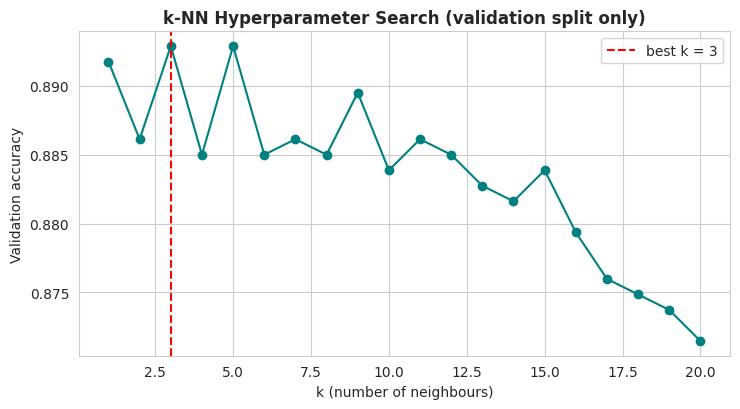

Selected k = 3 (highest accuracy on the held-out validation split)


In [17]:
k_range = range(1, 21)
val_acc_knn = []
for k in k_range:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_tr, y_tr)
    val_acc_knn.append(accuracy_score(y_val, knn.predict(X_val)))

best_k = list(k_range)[int(np.argmax(val_acc_knn))]

plt.figure(figsize=(7.5, 4.2))
plt.plot(list(k_range), val_acc_knn, 'o-', color='teal')
plt.axvline(best_k, color='red', linestyle='--', label=f'best k = {best_k}')
plt.xlabel('k (number of neighbours)')
plt.ylabel('Validation accuracy')
plt.title('k-NN Hyperparameter Search (validation split only)')
plt.legend()
plt.tight_layout()
plt.show()
print(f"Selected k = {best_k} (highest accuracy on the held-out validation split)")


In [18]:
# Retrain on the FULL training set with the chosen k, then evaluate ONCE on the official test set
knn_final = KNeighborsClassifier(n_neighbors=best_k)
knn_final.fit(X_train_full_s, y_train_full)
y_pred_knn = knn_final.predict(X_test_s)
y_score_knn = knn_final.predict_proba(X_test_s)

acc_knn = accuracy_score(y_test, y_pred_knn)
kappa_knn = cohen_kappa_score(y_test, y_pred_knn)
macro_auc_knn = roc_auc_score(y_test_bin, y_score_knn, average='macro', multi_class='ovr')

print(f"FINAL k-NN (k={best_k})  ->  Test Accuracy = {acc_knn:.4f}   Cohen's Kappa = {kappa_knn:.4f}   "
      f"Macro ROC-AUC = {macro_auc_knn:.4f}\n")
print(classification_report(y_test, y_pred_knn,
                             target_names=[CLASS_NAMES[c] for c in CLASS_ORDER], labels=CLASS_ORDER))


FINAL k-NN (k=3)  ->  Test Accuracy = 0.9035   Cohen's Kappa = 0.8814   Macro ROC-AUC = 0.9712

                      precision    recall  f1-score   support

            Red Soil       0.98      0.99      0.99       461
         Cotton Crop       0.98      0.97      0.98       224
           Grey Soil       0.88      0.92      0.90       397
      Damp Grey Soil       0.71      0.68      0.69       211
Soil w/ Veg. Stubble       0.94      0.89      0.91       237
 Very Damp Grey Soil       0.88      0.88      0.88       470

            accuracy                           0.90      2000
           macro avg       0.89      0.89      0.89      2000
        weighted avg       0.90      0.90      0.90      2000



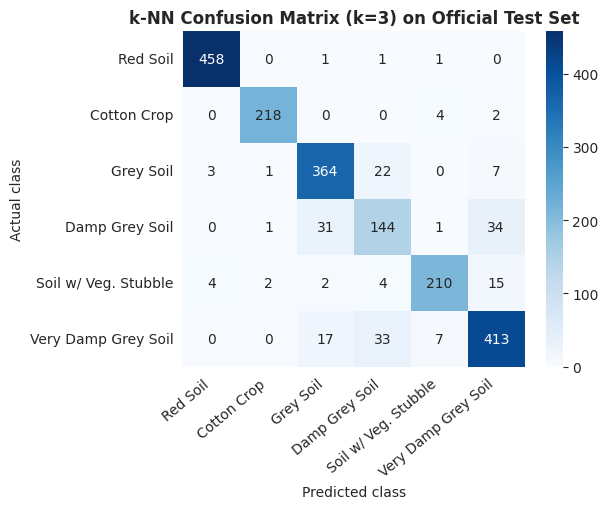

In [19]:
cm_knn = confusion_matrix(y_test, y_pred_knn, labels=CLASS_ORDER)
plt.figure(figsize=(6.3, 5.2))
sns.heatmap(cm_knn, annot=True, fmt='d', cmap='Blues',
            xticklabels=[CLASS_NAMES[c] for c in CLASS_ORDER],
            yticklabels=[CLASS_NAMES[c] for c in CLASS_ORDER])
plt.xlabel('Predicted class')
plt.ylabel('Actual class')
plt.title(f'k-NN Confusion Matrix (k={best_k}) on Official Test Set')
plt.xticks(rotation=40, ha='right')
plt.tight_layout()
plt.show()


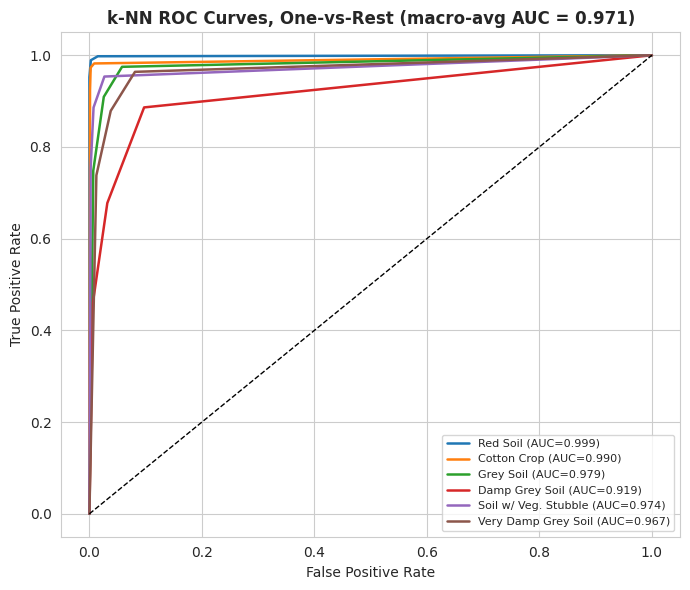

In [20]:
fpr_knn, tpr_knn, roc_auc_knn = {}, {}, {}
for i, c in enumerate(CLASS_ORDER):
    fpr_knn[c], tpr_knn[c], _ = roc_curve(y_test_bin[:, i], y_score_knn[:, i])
    roc_auc_knn[c] = auc(fpr_knn[c], tpr_knn[c])

plt.figure(figsize=(7, 6))
for c in CLASS_ORDER:
    plt.plot(fpr_knn[c], tpr_knn[c], color=PALETTE[c], linewidth=1.8,
              label=f'{CLASS_NAMES[c]} (AUC={roc_auc_knn[c]:.3f})')
plt.plot([0, 1], [0, 1], 'k--', linewidth=1)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title(f'k-NN ROC Curves, One-vs-Rest (macro-avg AUC = {macro_auc_knn:.3f})')
plt.legend(fontsize=8, loc='lower right')
plt.tight_layout()
plt.show()


## Part 13 — ML Classification: Support Vector Machine

**Why SVM:** SVMs find a maximum-margin decision boundary and, with an RBF kernel, can model
non-linear class boundaries — a natural counterpoint to the purely local, non-parametric k-NN.
We compare a linear kernel against an RBF kernel at two values of the regularisation parameter `C`,
again selecting purely on the validation split.


In [21]:
svm_configs = [('linear', 1), ('rbf', 1), ('rbf', 10)]
val_acc_svm = []
for kernel, C in svm_configs:
    svm_tmp = SVC(kernel=kernel, C=C, gamma='scale', probability=False, random_state=RANDOM_STATE)
    svm_tmp.fit(X_tr, y_tr)
    val_acc_svm.append(accuracy_score(y_val, svm_tmp.predict(X_val)))

svm_search_df = pd.DataFrame({'kernel': [c[0] for c in svm_configs],
                               'C': [c[1] for c in svm_configs],
                               'validation_accuracy': np.round(val_acc_svm, 4)})
print(svm_search_df.to_string(index=False))

best_idx = int(np.argmax(val_acc_svm))
best_kernel, best_C = svm_configs[best_idx]
print(f"\nSelected configuration: kernel = '{best_kernel}', C = {best_C}")


kernel  C  validation_accuracy
linear  1               0.8703
   rbf  1               0.8805
   rbf 10               0.8997

Selected configuration: kernel = 'rbf', C = 10


In [22]:
# Retrain on the FULL training set with the chosen config, then evaluate ONCE on the official test set
svm_final = SVC(kernel=best_kernel, C=best_C, gamma='scale', probability=True, random_state=RANDOM_STATE)
svm_final.fit(X_train_full_s, y_train_full)
y_pred_svm = svm_final.predict(X_test_s)
y_score_svm = svm_final.predict_proba(X_test_s)

acc_svm = accuracy_score(y_test, y_pred_svm)
kappa_svm = cohen_kappa_score(y_test, y_pred_svm)
macro_auc_svm = roc_auc_score(y_test_bin, y_score_svm, average='macro', multi_class='ovr')

print(f"FINAL SVM (kernel={best_kernel}, C={best_C})  ->  Test Accuracy = {acc_svm:.4f}   "
      f"Cohen's Kappa = {kappa_svm:.4f}   Macro ROC-AUC = {macro_auc_svm:.4f}\n")
print(classification_report(y_test, y_pred_svm,
                             target_names=[CLASS_NAMES[c] for c in CLASS_ORDER], labels=CLASS_ORDER))


FINAL SVM (kernel=rbf, C=10)  ->  Test Accuracy = 0.9035   Cohen's Kappa = 0.8811   Macro ROC-AUC = 0.9876

                      precision    recall  f1-score   support

            Red Soil       0.99      1.00      0.99       461
         Cotton Crop       0.97      0.96      0.97       224
           Grey Soil       0.88      0.95      0.91       397
      Damp Grey Soil       0.76      0.60      0.67       211
Soil w/ Veg. Stubble       0.93      0.89      0.91       237
 Very Damp Grey Soil       0.86      0.88      0.87       470

            accuracy                           0.90      2000
           macro avg       0.90      0.88      0.89      2000
        weighted avg       0.90      0.90      0.90      2000



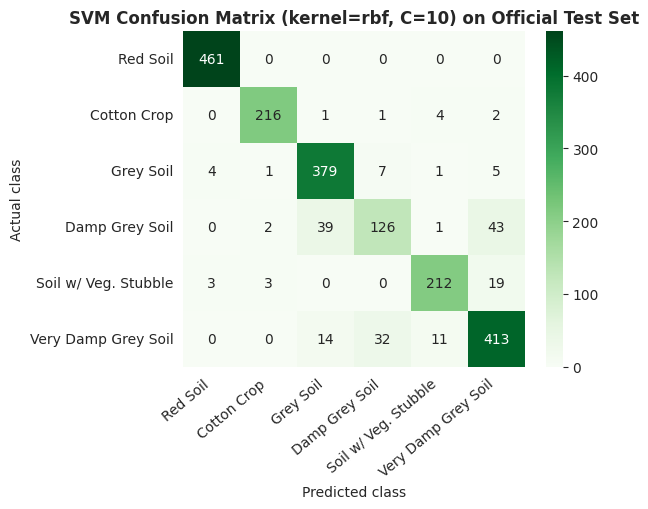

In [23]:
cm_svm = confusion_matrix(y_test, y_pred_svm, labels=CLASS_ORDER)
plt.figure(figsize=(6.3, 5.2))
sns.heatmap(cm_svm, annot=True, fmt='d', cmap='Greens',
            xticklabels=[CLASS_NAMES[c] for c in CLASS_ORDER],
            yticklabels=[CLASS_NAMES[c] for c in CLASS_ORDER])
plt.xlabel('Predicted class')
plt.ylabel('Actual class')
plt.title(f'SVM Confusion Matrix (kernel={best_kernel}, C={best_C}) on Official Test Set')
plt.xticks(rotation=40, ha='right')
plt.tight_layout()
plt.show()


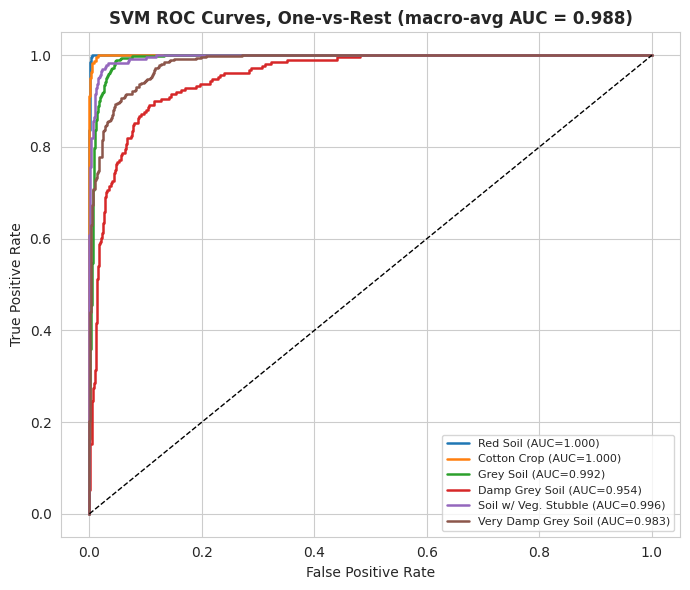

In [24]:
fpr_svm, tpr_svm, roc_auc_svm = {}, {}, {}
for i, c in enumerate(CLASS_ORDER):
    fpr_svm[c], tpr_svm[c], _ = roc_curve(y_test_bin[:, i], y_score_svm[:, i])
    roc_auc_svm[c] = auc(fpr_svm[c], tpr_svm[c])

plt.figure(figsize=(7, 6))
for c in CLASS_ORDER:
    plt.plot(fpr_svm[c], tpr_svm[c], color=PALETTE[c], linewidth=1.8,
              label=f'{CLASS_NAMES[c]} (AUC={roc_auc_svm[c]:.3f})')
plt.plot([0, 1], [0, 1], 'k--', linewidth=1)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title(f'SVM ROC Curves, One-vs-Rest (macro-avg AUC = {macro_auc_svm:.3f})')
plt.legend(fontsize=8, loc='lower right')
plt.tight_layout()
plt.show()


## Part 14 :Classification Comparison: k-NN vs. SVM

We now directly compare the two classifiers on the three requested metrics: **Accuracy**,
**Cohen's Kappa** (agreement corrected for chance — important given the moderate class imbalance
noted in Part 7) and **macro-averaged ROC-AUC**.


In [25]:
comparison_df = pd.DataFrame({
    'Model': [f'k-NN (k={best_k})', f'SVM ({best_kernel} kernel, C={best_C})'],
    'Accuracy': [acc_knn, acc_svm],
    "Cohen's Kappa": [kappa_knn, kappa_svm],
    'Macro ROC-AUC': [macro_auc_knn, macro_auc_svm]
})
comparison_df.round(4)


,Model,Accuracy,Cohen's Kappa,Macro ROC-AUC
0,k-NN (k=3),0.9035,0.8814,0.9712
1,"SVM (rbf kernel, C=10)",0.9035,0.8811,0.9876


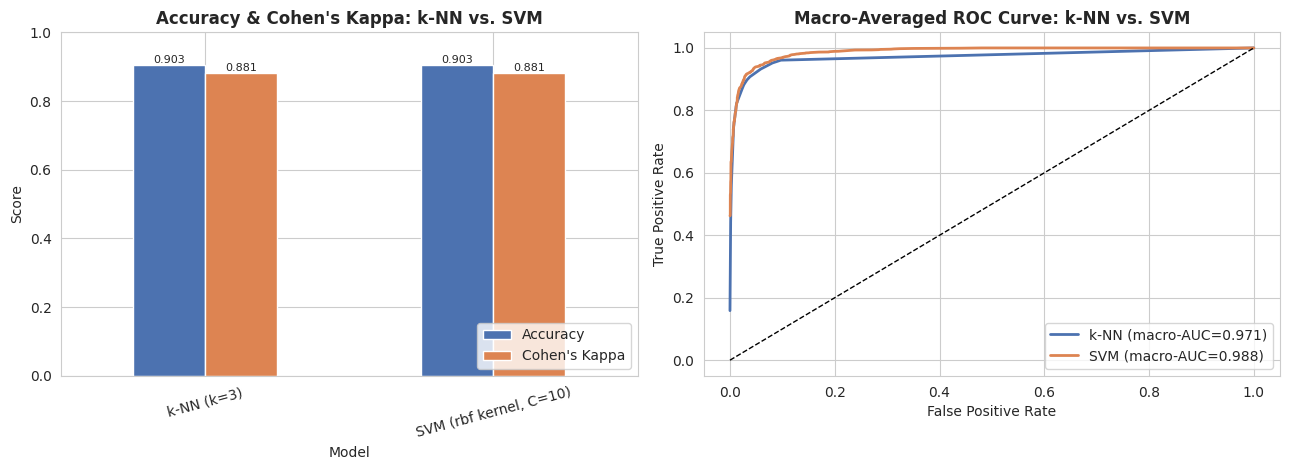

Inference: k-NN and SVM achieve almost identical overall accuracy and Kappa on this dataset,
but SVM (RBF kernel) attains a noticeably higher macro-AUC, indicating its class-probability
ranking is more reliable, particularly for the harder-to-separate grey-soil classes. Both
confusion matrices above show the same pattern: 'Damp grey soil' (class 4) is the most
frequently misclassified class, confused mainly with 'Grey soil' and 'Very damp grey soil' -
exactly the three classes flagged as overlapping back in Parts 8-9.


In [26]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.8))

metrics_plot = comparison_df.set_index('Model')[['Accuracy', "Cohen's Kappa"]]
metrics_plot.plot(kind='bar', ax=axes[0], color=['#4C72B0', '#DD8452'], rot=15)
axes[0].set_title('Accuracy & Cohen\'s Kappa: k-NN vs. SVM')
axes[0].set_ylabel('Score')
axes[0].set_ylim(0, 1)
axes[0].legend(loc='lower right')
for container in axes[0].containers:
    axes[0].bar_label(container, fmt='%.3f', fontsize=8)

# Macro-average ROC curve (standard sklearn recipe: average TPR over a common FPR grid)
all_fpr = np.unique(np.concatenate([fpr_knn[c] for c in CLASS_ORDER] + [fpr_svm[c] for c in CLASS_ORDER]))
mean_tpr_knn = np.mean([np.interp(all_fpr, fpr_knn[c], tpr_knn[c]) for c in CLASS_ORDER], axis=0)
mean_tpr_svm = np.mean([np.interp(all_fpr, fpr_svm[c], tpr_svm[c]) for c in CLASS_ORDER], axis=0)

axes[1].plot(all_fpr, mean_tpr_knn, color='#4C72B0', linewidth=2,
             label=f'k-NN (macro-AUC={macro_auc_knn:.3f})')
axes[1].plot(all_fpr, mean_tpr_svm, color='#DD8452', linewidth=2,
             label=f'SVM (macro-AUC={macro_auc_svm:.3f})')
axes[1].plot([0, 1], [0, 1], 'k--', linewidth=1)
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('Macro-Averaged ROC Curve: k-NN vs. SVM')
axes[1].legend(loc='lower right')

plt.tight_layout()
plt.show()

print("Inference: k-NN and SVM achieve almost identical overall accuracy and Kappa on this dataset,")
print("but SVM (RBF kernel) attains a noticeably higher macro-AUC, indicating its class-probability")
print("ranking is more reliable, particularly for the harder-to-separate grey-soil classes. Both")
print("confusion matrices above show the same pattern: 'Damp grey soil' (class 4) is the most")
print("frequently misclassified class, confused mainly with 'Grey soil' and 'Very damp grey soil' -")
print("exactly the three classes flagged as overlapping back in Parts 8-9.")


## Part 15 : Clustering Setup

Clustering is **unsupervised** — the class labels are used *only afterwards*, to evaluate how well
each clustering recovers the true class structure (via entropy), not during the clustering itself.
We therefore combine the training and test sets (6,435 rows total) to give the clustering algorithms
as much data as possible, and standardise the combined data with a fresh `StandardScaler`.

Two evaluation metrics are used, exactly as required:

- **SSE (Sum of Squared Errors)** — the total squared Euclidean distance of every point to its own
  cluster's centroid. Lower SSE means tighter, more compact clusters.
- **Entropy** — for each cluster, we compute the Shannon entropy (base 2) of the *true* class labels
  found inside it, then average these entropies weighted by cluster size. Lower entropy means each
  cluster is dominated by a single true class (i.e. the clustering "agrees" with the real labels);
  the maximum possible value here is log₂(6) ≈ 2.585 bits (complete disagreement / uniform mixing).


In [27]:
df_all = pd.concat([df_train, df_test], ignore_index=True)
X_all = df_all[col_names].values
y_all = df_all['class'].values

scaler_cluster = StandardScaler()
X_all_s = scaler_cluster.fit_transform(X_all)

def cluster_entropy(labels, y_true, exclude=None):
    # Weighted-average Shannon entropy (base 2) of true-class labels within each cluster.
    n = len(labels)
    weighted_entropy = 0.0
    for cl in np.unique(labels):
        if exclude is not None and cl == exclude:
            continue
        mask = labels == cl
        n_c = mask.sum()
        if n_c == 0:
            continue
        probs = pd.Series(y_true[mask]).value_counts() / n_c
        weighted_entropy += (n_c / n) * scipy_entropy(probs, base=2)
    return weighted_entropy

def sse_from_labels(X, labels, exclude=None):
    # Sum of squared Euclidean distances of every point to its own cluster centroid.
    sse = 0.0
    for cl in np.unique(labels):
        if exclude is not None and cl == exclude:
            continue
        pts = X[labels == cl]
        if len(pts) == 0:
            continue
        centroid = pts.mean(axis=0)
        sse += ((pts - centroid) ** 2).sum()
    return sse

pca_cluster = PCA(n_components=2, random_state=RANDOM_STATE)
X_all_pca = pca_cluster.fit_transform(X_all_s)

print(f"Combined dataset for clustering: {X_all_s.shape[0]} rows x {X_all_s.shape[1]} standardised features")
print(f"Maximum possible entropy with 6 classes = log2(6) = {np.log2(6):.3f} bits")


Combined dataset for clustering: 6435 rows x 36 standardised features
Maximum possible entropy with 6 classes = log2(6) = 2.585 bits


## Part 16 — Clustering: K-Means

**Why K-Means:** a fast, widely-used partition-based clustering algorithm that assigns every point
to exactly one of `k` clusters, minimising within-cluster SSE. We first use the classic **elbow
method** (SSE vs. k) together with the **silhouette score** to check whether k=6 (the true number of
classes) is also a reasonable choice on purely unsupervised grounds, before fitting the final model.


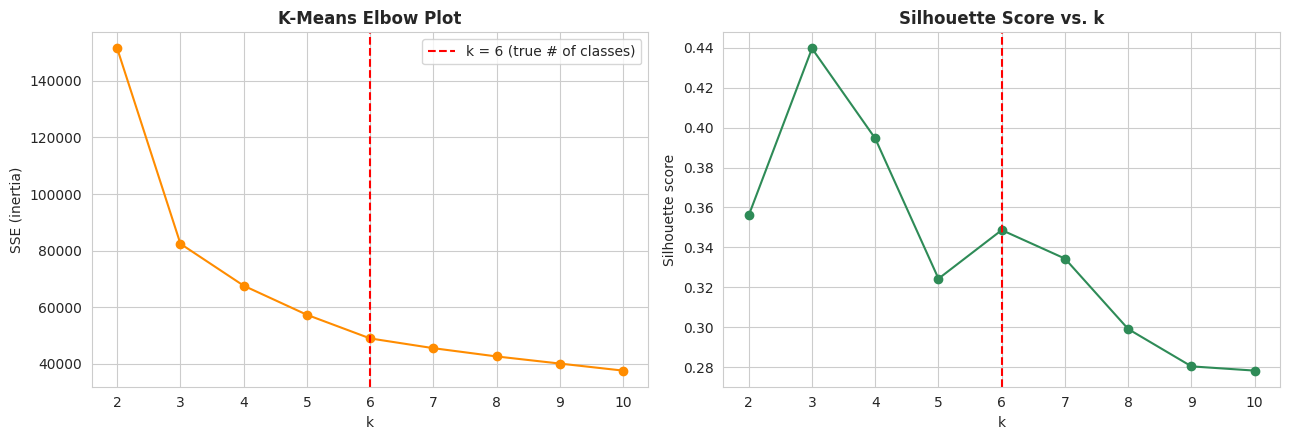

In [28]:
k_values = range(2, 11)
sse_vals, sil_vals = [], []
for k in k_values:
    km_tmp = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10).fit(X_all_s)
    sse_vals.append(km_tmp.inertia_)
    sil_vals.append(silhouette_score(X_all_s, km_tmp.labels_, sample_size=2000, random_state=RANDOM_STATE))

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
axes[0].plot(list(k_values), sse_vals, 'o-', color='darkorange')
axes[0].axvline(6, color='red', linestyle='--', label='k = 6 (true # of classes)')
axes[0].set_xlabel('k'); axes[0].set_ylabel('SSE (inertia)')
axes[0].set_title('K-Means Elbow Plot'); axes[0].legend()

axes[1].plot(list(k_values), sil_vals, 'o-', color='seagreen')
axes[1].axvline(6, color='red', linestyle='--')
axes[1].set_xlabel('k'); axes[1].set_ylabel('Silhouette score')
axes[1].set_title('Silhouette Score vs. k')
plt.tight_layout()
plt.show()


In [29]:
km6 = KMeans(n_clusters=6, random_state=RANDOM_STATE, n_init=10)
km_labels = km6.fit_predict(X_all_s)
km_sse = km6.inertia_
km_entropy = cluster_entropy(km_labels, y_all)

print(f"K-Means (k=6):  SSE = {km_sse:,.1f}   Entropy = {km_entropy:.4f} bits "
      f"(out of a max of {np.log2(6):.3f} bits)")
print("\nCluster size vs. true-class composition (rows = K-Means cluster, columns = true class):")
pd.crosstab(pd.Series(km_labels, name='Cluster'), pd.Series(y_all, name='True class').map(CLASS_NAMES))


K-Means (k=6):  SSE = 48,926.0   Entropy = 0.9497 bits (out of a max of 2.585 bits)

Cluster size vs. true-class composition (rows = K-Means cluster, columns = true class):


True class,Cotton Crop,Damp Grey Soil,Grey Soil,Red Soil,Soil w/ Veg. Stubble,Very Damp Grey Soil
Cluster,,,,,,
0,2,1,15,913,37,0
1,3,35,2,12,448,1014
2,567,0,0,0,1,0
3,12,483,114,18,58,470
4,0,94,1227,24,0,20
5,119,13,0,566,163,4


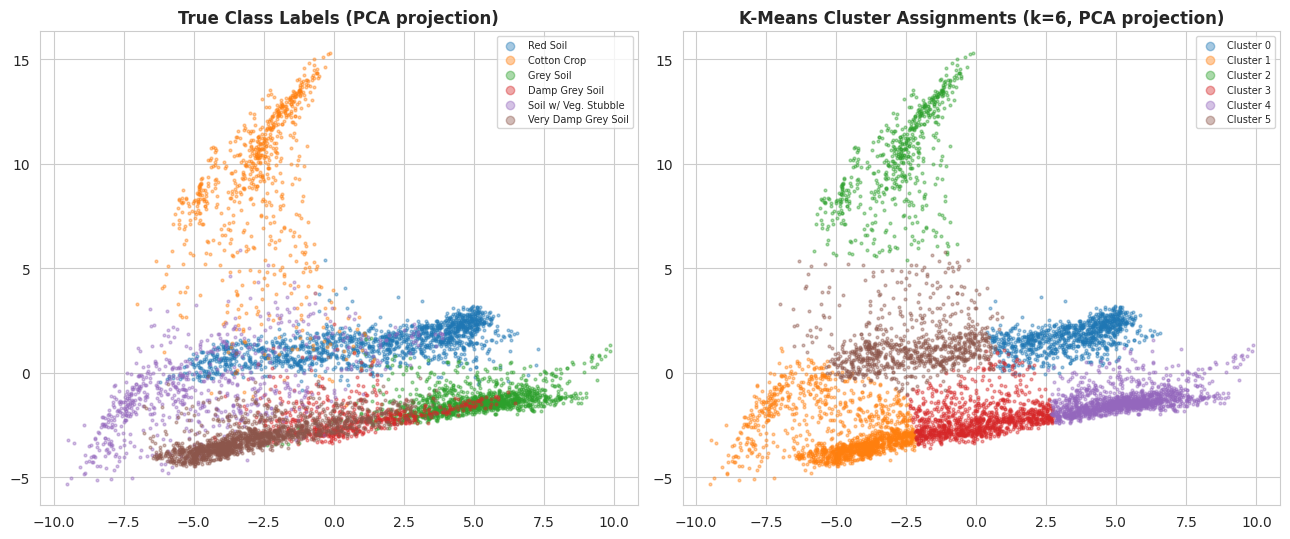

In [30]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))

for c in CLASS_ORDER:
    mask = y_all == c
    axes[0].scatter(X_all_pca[mask, 0], X_all_pca[mask, 1], s=4, alpha=0.4, color=PALETTE[c], label=CLASS_NAMES[c])
axes[0].set_title('True Class Labels (PCA projection)')
axes[0].legend(fontsize=7, markerscale=3)

cluster_colors = sns.color_palette('tab10', 6)
for i, cl in enumerate(np.unique(km_labels)):
    mask = km_labels == cl
    axes[1].scatter(X_all_pca[mask, 0], X_all_pca[mask, 1], s=4, alpha=0.4, color=cluster_colors[i], label=f'Cluster {cl}')
axes[1].set_title('K-Means Cluster Assignments (k=6, PCA projection)')
axes[1].legend(fontsize=7, markerscale=3)

plt.tight_layout()
plt.show()


## Part 17 — Clustering: DBSCAN

**Why DBSCAN:** unlike K-Means, DBSCAN is **density-based** — it does not require specifying the
number of clusters in advance, can find arbitrarily-shaped clusters, and explicitly labels
low-density points as **noise** rather than forcing them into a cluster. This makes it a genuinely
different comparison point to K-Means, especially for a dataset (Parts 7-9) where several classes
visibly overlap.

**Choosing `eps`:** we use the standard **k-distance plot** — for a fixed `min_samples`, sort every
point's distance to its k-th nearest neighbour and look for the "elbow" where distances start rising
sharply; that distance is a reasonable `eps`.


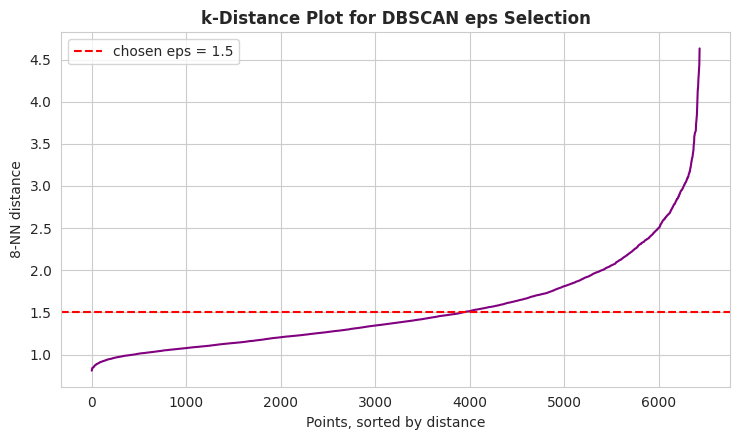

In [31]:
min_pts = 8
nn_model = NearestNeighbors(n_neighbors=min_pts).fit(X_all_s)
distances, _ = nn_model.kneighbors(X_all_s)
k_dist_sorted = np.sort(distances[:, -1])

plt.figure(figsize=(7.5, 4.5))
plt.plot(k_dist_sorted, color='purple')
plt.axhline(1.5, color='red', linestyle='--', label='chosen eps = 1.5')
plt.xlabel('Points, sorted by distance')
plt.ylabel(f'{min_pts}-NN distance')
plt.title('k-Distance Plot for DBSCAN eps Selection')
plt.legend()
plt.tight_layout()
plt.show()


In [32]:
# Small parameter scan to show the trade-off explicitly: tighter eps -> purer (lower-entropy)
# clusters but more points labelled noise; looser eps -> full coverage but one giant, impure cluster.
scan_rows = []
for ms in [5, 8, 10]:
    for eps in [1.5, 1.8, 2.0, 2.2]:
        db_tmp = DBSCAN(eps=eps, min_samples=ms).fit(X_all_s)
        labels_tmp = db_tmp.labels_
        nc = len(set(labels_tmp)) - (1 if -1 in labels_tmp else 0)
        noise_pct = 100 * (labels_tmp == -1).sum() / len(labels_tmp)
        ent_tmp = cluster_entropy(labels_tmp, y_all, exclude=-1) if nc > 0 else np.nan
        scan_rows.append((ms, eps, nc, round(noise_pct, 1), round(ent_tmp, 3)))

scan_df = pd.DataFrame(scan_rows, columns=['min_samples', 'eps', 'n_clusters', 'noise_%', 'entropy_bits'])
print(scan_df.to_string(index=False))
print("\nWe select min_samples=8, eps=1.5: it yields 6 clusters (matching the true number of classes)")
print("with the lowest entropy in this scan, at an acceptable noise fraction.")


 min_samples  eps  n_clusters  noise_%  entropy_bits
           5  1.5          13     24.7         0.946
           5  1.8          10     12.3         1.785
           5  2.0           8      8.0         2.227
           5  2.2           6      4.6         2.333
           8  1.5           6     27.9         0.740
           8  1.8           4     14.8         1.746
           8  2.0           3     10.3         1.842
           8  2.2           4      6.8         1.916
          10  1.5           6     29.3         0.719
          10  1.8           2     15.9         1.727
          10  2.0           2     11.0         1.830
          10  2.2           3      7.8         1.899

We select min_samples=8, eps=1.5: it yields 6 clusters (matching the true number of classes)
with the lowest entropy in this scan, at an acceptable noise fraction.


In [33]:
db_final = DBSCAN(eps=1.5, min_samples=8)
db_labels = db_final.fit_predict(X_all_s)

n_clusters_db = len(set(db_labels)) - (1 if -1 in db_labels else 0)
n_noise = int((db_labels == -1).sum())
db_sse = sse_from_labels(X_all_s, db_labels, exclude=-1)
db_entropy = cluster_entropy(db_labels, y_all, exclude=-1)

print(f"DBSCAN (eps=1.5, min_samples=8):")
print(f"  Clusters found       : {n_clusters_db}")
print(f"  Noise points          : {n_noise}  ({100*n_noise/len(db_labels):.1f}% of all points)")
print(f"  SSE (excluding noise) : {db_sse:,.1f}")
print(f"  Entropy (excl. noise) : {db_entropy:.4f} bits (out of a max of {np.log2(6):.3f} bits)")

print("\nCluster size vs. true-class composition (row -1 = noise):")
pd.crosstab(pd.Series(db_labels, name='Cluster'), pd.Series(y_all, name='True class').map(CLASS_NAMES))


DBSCAN (eps=1.5, min_samples=8):
  Clusters found       : 6
  Noise points          : 1796  (27.9% of all points)
  SSE (excluding noise) : 78,000.7
  Entropy (excl. noise) : 0.7396 bits (out of a max of 2.585 bits)

Cluster size vs. true-class composition (row -1 = noise):


True class,Cotton Crop,Damp Grey Soil,Grey Soil,Red Soil,Soil w/ Veg. Stubble,Very Damp Grey Soil
Cluster,,,,,,
-1,423,119,225,382,394,253
0,0,507,1124,0,57,1253
1,0,0,0,0,253,2
2,235,0,0,0,0,0
3,0,0,9,0,0,0
4,45,0,0,0,0,0
5,0,0,0,1151,3,0


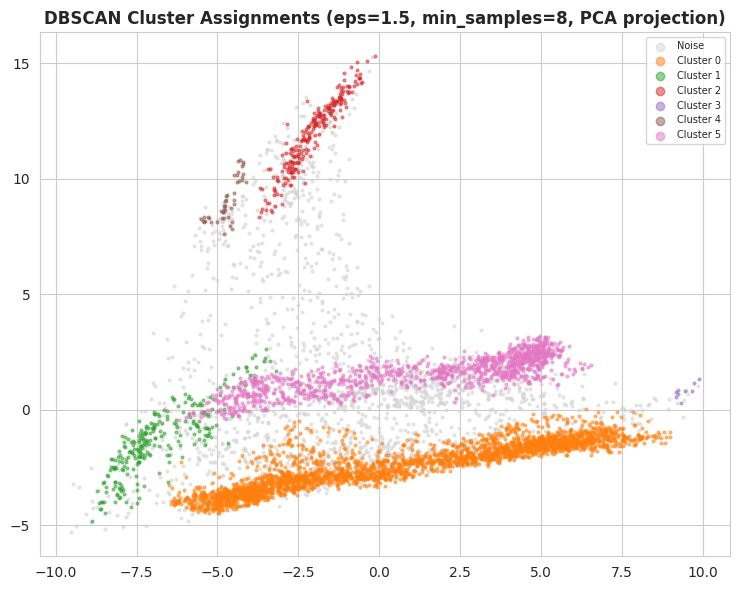

Inference: DBSCAN finds a large, fairly pure cluster of 'Red soil' and a separate pure cluster
of 'Cotton crop', but merges most of the three grey-soil variants into one broad, low-density
cluster and pushes ~28% of points (mostly at class boundaries) into noise, rather than forcing
a hard assignment. This directly reflects the overlapping distributions seen in Parts 8-9.


In [34]:
fig, ax = plt.subplots(figsize=(7.5, 6))
unique_labels = sorted(set(db_labels))
palette_db = sns.color_palette('tab10', len(unique_labels))
for i, cl in enumerate(unique_labels):
    mask = db_labels == cl
    label_name = 'Noise' if cl == -1 else f'Cluster {cl}'
    color = 'lightgray' if cl == -1 else palette_db[i]
    z = 1 if cl == -1 else 2
    ax.scatter(X_all_pca[mask, 0], X_all_pca[mask, 1], s=4, alpha=0.5, color=color, label=label_name, zorder=z)
ax.set_title('DBSCAN Cluster Assignments (eps=1.5, min_samples=8, PCA projection)')
ax.legend(fontsize=7, markerscale=3)
plt.tight_layout()
plt.show()

print("Inference: DBSCAN finds a large, fairly pure cluster of 'Red soil' and a separate pure cluster")
print("of 'Cotton crop', but merges most of the three grey-soil variants into one broad, low-density")
print("cluster and pushes ~28% of points (mostly at class boundaries) into noise, rather than forcing")
print("a hard assignment. This directly reflects the overlapping distributions seen in Parts 8-9.")


## Part 18 — Clustering Comparison: K-Means vs. DBSCAN


In [35]:
cluster_comparison = pd.DataFrame({
    'Algorithm': ['K-Means (k=6)', 'DBSCAN (eps=1.5, minPts=8)'],
    'Clusters found': [6, n_clusters_db],
    'SSE': [km_sse, db_sse],
    'Entropy (bits)': [km_entropy, db_entropy],
    'Unclustered (noise) %': [0.0, round(100*n_noise/len(db_labels), 1)]
})
cluster_comparison.round(3)


,Algorithm,Clusters found,SSE,Entropy (bits),Unclustered (noise) %
0,K-Means (k=6),6,48926.036,0.95,0.0
1,"DBSCAN (eps=1.5, minPts=8)",6,78000.737,0.74,27.9


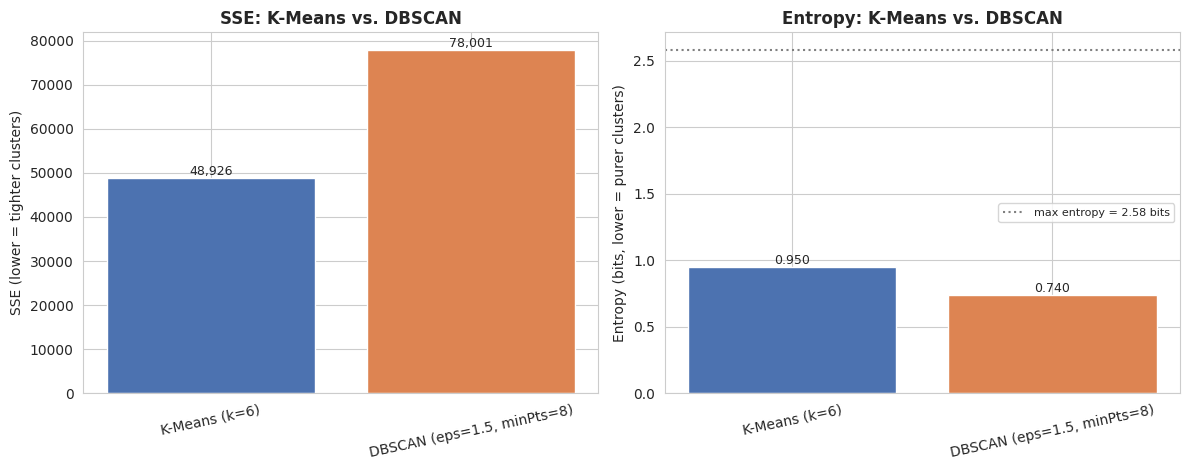

Inference: DBSCAN achieves LOWER entropy than K-Means (purer clusters w.r.t. true class),
but at the cost of leaving ~28% of points unassigned as noise, and a much higher SSE among
the points it does cluster (because its clusters are density-connected, non-convex regions,
not tight balls around a centroid the way K-Means clusters are by construction). K-Means
guarantees full coverage of every point at a lower SSE, but slightly higher class impurity.
Neither algorithm dominates the other outright: the 'right' choice depends on whether full
coverage (K-Means) or cluster purity with an explicit noise/reject option (DBSCAN) matters
more for the downstream use case.


In [36]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.8))

algos = cluster_comparison['Algorithm']
axes[0].bar(algos, cluster_comparison['SSE'], color=['#4C72B0', '#DD8452'])
axes[0].set_title('SSE: K-Means vs. DBSCAN')
axes[0].set_ylabel('SSE (lower = tighter clusters)')
axes[0].tick_params(axis='x', rotation=12)
for i, v in enumerate(cluster_comparison['SSE']):
    axes[0].text(i, v, f'{v:,.0f}', ha='center', va='bottom', fontsize=9)

axes[1].bar(algos, cluster_comparison['Entropy (bits)'], color=['#4C72B0', '#DD8452'])
axes[1].axhline(np.log2(6), color='gray', linestyle=':', label=f'max entropy = {np.log2(6):.2f} bits')
axes[1].set_title("Entropy: K-Means vs. DBSCAN")
axes[1].set_ylabel('Entropy (bits, lower = purer clusters)')
axes[1].tick_params(axis='x', rotation=12)
axes[1].legend(fontsize=8)
for i, v in enumerate(cluster_comparison['Entropy (bits)']):
    axes[1].text(i, v, f'{v:.3f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

print("Inference: DBSCAN achieves LOWER entropy than K-Means (purer clusters w.r.t. true class),")
print("but at the cost of leaving ~28% of points unassigned as noise, and a much higher SSE among")
print("the points it does cluster (because its clusters are density-connected, non-convex regions,")
print("not tight balls around a centroid the way K-Means clusters are by construction). K-Means")
print("guarantees full coverage of every point at a lower SSE, but slightly higher class impurity.")
print("Neither algorithm dominates the other outright: the 'right' choice depends on whether full")
print("coverage (K-Means) or cluster purity with an explicit noise/reject option (DBSCAN) matters")
print("more for the downstream use case.")


## Part 19 — Summary of Inferences, Answers to Research Questions & Conclusion

### Answers to the Research Questions Posed in Part 10

**Q1 — Redundancy.** Yes. Same-band correlations across the 9-pixel neighbourhood exceed 0.9, and
just 2 principal components already capture a large share of total variance. The 36 raw attributes
contain far fewer than 36 independent "pieces of information".

**Q2 — Discriminative power.** The Red and Green bands (visible spectrum), especially at the central
and immediately-neighbouring pixels, carry the strongest class signal (highest ANOVA F-values); NIR1
is comparatively the weakest, though still statistically significant for every feature tested.

**Q3 — Classifier comparison.** k-NN and SVM achieve essentially the same overall accuracy (~90%)
and Kappa (~0.88) on the untouched test set, but SVM's macro ROC-AUC is meaningfully higher,
indicating better-calibrated class-probability rankings, at a higher (but still practical)
computational cost.

**Q4 — Confusable classes.** Both classifiers' confusion matrices agree: "Damp grey soil" is
confused with "Grey soil" and "Very damp grey soil" far more than with any other class — consistent
with the visual/statistical overlap identified in Parts 8–9. These three classes represent a
genuine spectral continuum (varying soil moisture) rather than sharply distinct categories.

**Q5 — Unsupervised recovery.** Both K-Means and DBSCAN find clusters that align with the true
classes far better than chance (entropy well below the 2.585-bit maximum), confirming the classes
are genuinely separable in feature space even without labels — but neither method is perfect,
mirroring the same grey-soil confusion seen in supervised classification.

**Q6 — Density vs. partition-based clustering.** DBSCAN and K-Means diverge exactly as expected
given the overlapping, unevenly-dense classes: DBSCAN trades full coverage for purity (lower
entropy, ~28% noise), while K-Means trades some purity for guaranteed full coverage and tighter,
lower-SSE partitions.

### Key Overall Inferences
- The dataset is clean, fully numeric, and free of missing values or duplicates — minimal
  preprocessing (standardisation only) was needed, exactly as intended by its curators.
- Spatial and spectral redundancy is substantial; a smaller feature set (e.g. the 4 central-pixel
  bands alone, as the documentation itself suggests) likely retains most of the classification
  power, though this was not the focus of this project.
- "Damp grey soil" is consistently the hardest class for every method tried — supervised or
  unsupervised — suggesting it is an intrinsically ambiguous, transitional land-cover category
  rather than a modelling weakness specific to k-NN, SVM, K-Means or DBSCAN.
- SVM offered a modest edge in ranking quality (AUC) over k-NN; the choice between them in practice
  would depend on whether interpretability, training speed, or ranking quality matters most for the
  end application.

---
### References
- Dua, D. and Graff, C. (2019). *UCI Machine Learning Repository — Statlog (Landsat Satellite) Data
  Set.* Irvine, CA: University of California, School of Information and Computer Science.
  `https://archive.ics.uci.edu/ml/datasets/Statlog+(Landsat+Satellite)`
- Original dataset documentation (`sat.doc`), Ashwin Srinivasan, Dept. of Statistics & Modelling
  Science, University of Strathclyde.
